# Cardinal Buoy Classification with CNN
Deep Learning approach using Convolutional Neural Networks with Data Augmentation

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

%run setup.ipynb

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

I0000 00:00:1779175335.153122   14105 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779175335.634081   14105 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1779175337.368602   14105 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


dataset_root : /home/elias/Documents/FISE/Projet_image2/Project datasets
DETECTION_METHOD : algo
East: 36 images


North: 59 images


South: 38 images


West: 34 images


Dataset chargé : 167 images, taille (128, 128)
Distribution   : {'East': 36, 'North': 59, 'South': 38, 'West': 34}
TensorFlow version: 2.21.0
GPU available: False


E0000 00:00:1779175373.593902   14105 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [2]:
BATCH_SIZE = 32
EPOCHS     = 100  # early stopping coupe avant

X = X.astype('float32') / 255.0

print(f"Image size: {IMG_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Epochs max: {EPOCHS} (early stopping actif)")


Image size: (128, 128)
Batch size: 32
Epochs max: 100 (early stopping actif)


In [3]:
# Data augmentation configuration 
augmentation = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='reflect',
    brightness_range=[0.8, 1.2]
)


In [4]:
def build_cnn_model(input_shape=(128, 128, 3), num_classes=4):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.30),

        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.50),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

model = build_cnn_model()
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,172 (434.27 KB)

 Trainable params: 110,724 (432.52 KB)

 Non-trainable params: 448 (1.75 KB)

In [5]:
import time

AUGMENTATION_FACTOR = 3

skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)
fold_accuracies  = []
fold_histories   = []
fold_times       = []
all_y_true       = []
all_y_pred       = []
class_accuracies = {i: [] for i in range(4)}

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    print(f"\nFOLD {fold+1}/{CV_FOLDS}")

    X_train_full, X_test = X[train_idx], X[test_idx]
    y_train_full, y_test = y[train_idx], y[test_idx]

    # Split manuel train/val — val sans augmentation
    val_size = max(1, int(0.2 * len(X_train_full)))
    X_val,   y_val   = X_train_full[:val_size],  y_train_full[:val_size]
    X_train, y_train = X_train_full[val_size:],  y_train_full[val_size:]

    # Générateur on-the-fly : aucun np.concatenate en mémoire (problemes lors de l'entrainement précédent)
    train_gen       = augmentation.flow(X_train, y_train, batch_size=BATCH_SIZE)
    steps_per_epoch = max(1, len(X_train) * AUGMENTATION_FACTOR // BATCH_SIZE)

    print(f"  Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)} | Steps/epoch: {steps_per_epoch}")

    model = build_cnn_model()
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=15,
            restore_best_weights=True, verbose=0
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=7, min_lr=1e-5, verbose=0
        ),
    ]

    history = model.fit(
        train_gen,
        steps_per_epoch=steps_per_epoch,
        epochs=EPOCHS,
        validation_data=(X_val, y_val),
        callbacks=callbacks,
        verbose=0,
    )

    epochs_run   = len(history.history['loss'])
    best_val_acc = max(history.history['val_accuracy'])
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    fold_accuracies.append(test_acc)
    fold_histories.append(history)

    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    all_y_true.extend(y_test.tolist())
    all_y_pred.extend(y_pred.tolist())

    # Temps de traitement d'une nouvelle image test : forward pass du CNN
    # sur une image (128x128x3 deja normalisee).
    _ = model(X_test[:1], training=False)  # warm-up (compilation tf.function)
    per_image_times = []
    for i in range(len(X_test)):
        t0 = time.perf_counter()
        model(X_test[i:i+1], training=False)
        per_image_times.append(time.perf_counter() - t0)
    fold_times.append(np.mean(per_image_times))

    for class_id in range(4):
        mask = y_test == class_id
        if np.sum(mask) > 0:
            class_accuracies[class_id].append(np.mean(y_pred[mask] == y_test[mask]))

    print(f"  Stopped at epoch {epochs_run} | Best val acc: {best_val_acc:.1%} | Test acc: {test_acc:.1%} | Time/image: {fold_times[-1]*1000:.4f}ms")

mean_acc = np.mean(fold_accuracies)
std_acc  = np.std(fold_accuracies)
mean_time = np.mean(fold_times)

print(f"\nFINAL RESULTS")
print(f"Mean Accuracy: {mean_acc*100:.1f}% ± {std_acc*100:.1f}%")
for i, acc in enumerate(fold_accuracies):
    print(f"  Fold {i+1}: {acc*100:.1f}%")
print(f"Mean Time per Image: {mean_time*1000:.4f} ms")
print(f"\nPer-Class Accuracy:")
for class_id in range(4):
    if class_accuracies[class_id]:
        print(f"  {direction_names[class_id]}: {np.mean(class_accuracies[class_id]):.1%}")


FOLD 1/5


  Train: 107 | Val: 26 | Test: 34 | Steps/epoch: 10


I0000 00:00:1779175374.159346   14105 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


/home/elias/.venvs/fise-ml-global/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  Stopped at epoch 17 | Best val acc: 100.0% | Test acc: 23.5% | Time/image: 23.7387ms

FOLD 2/5
  Train: 107 | Val: 26 | Test: 34 | Steps/epoch: 10


  Stopped at epoch 17 | Best val acc: 7.7% | Test acc: 17.6% | Time/image: 22.4209ms

FOLD 3/5
  Train: 108 | Val: 26 | Test: 33 | Steps/epoch: 10


  Stopped at epoch 16 | Best val acc: 0.0% | Test acc: 36.4% | Time/image: 22.4941ms

FOLD 4/5
  Train: 108 | Val: 26 | Test: 33 | Steps/epoch: 10


  Stopped at epoch 32 | Best val acc: 100.0% | Test acc: 21.2% | Time/image: 21.4563ms

FOLD 5/5
  Train: 108 | Val: 26 | Test: 33 | Steps/epoch: 10


  Stopped at epoch 40 | Best val acc: 100.0% | Test acc: 33.3% | Time/image: 22.3981ms

FINAL RESULTS
Mean Accuracy: 26.4% ± 7.2%
  Fold 1: 23.5%
  Fold 2: 17.6%
  Fold 3: 36.4%
  Fold 4: 21.2%
  Fold 5: 33.3%
Mean Time per Image: 22.5016 ms

Per-Class Accuracy:
  East: 57.1%
  North: 21.7%
  South: 12.5%
  West: 14.3%


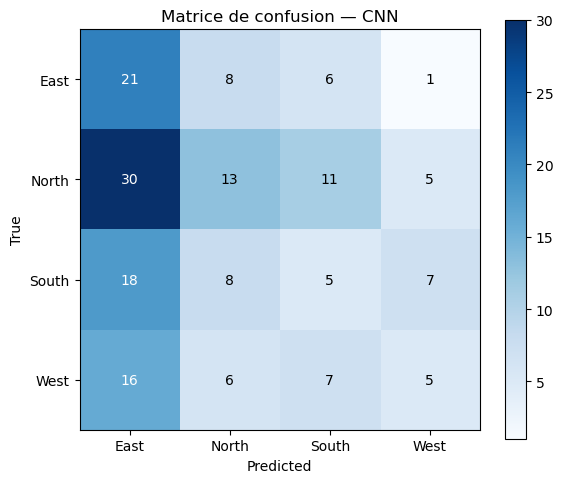

              precision    recall  f1-score   support

        East       0.25      0.58      0.35        36
       North       0.37      0.22      0.28        59
       South       0.17      0.13      0.15        38
        West       0.28      0.15      0.19        34

    accuracy                           0.26       167
   macro avg       0.27      0.27      0.24       167
weighted avg       0.28      0.26      0.25       167



In [6]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(all_y_true, all_y_pred)
class_names = [direction_names[i] for i in range(4)]

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
fig.colorbar(im, ax=ax)
ax.set(xticks=range(4), yticks=range(4),
       xticklabels=class_names, yticklabels=class_names,
       xlabel='Predicted', ylabel='True',
       title='Matrice de confusion — CNN')
for i in range(4):
    for j in range(4):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black')
plt.tight_layout()
plt.savefig('cnn_confusion_matrix.png', dpi=150)
plt.show()

print(classification_report(all_y_true, all_y_pred, target_names=class_names))
